## **Veriyi Anlama**

In [ ]:
import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive') #Drive'ı colab'a bağla. Çalışınca izin isteyecek.

Mounted at /content/drive


In [ ]:
FILE_PATH = '/content/drive/MyDrive/home_credit_default_risk/application_train.csv'

df = pd.read_csv(FILE_PATH)

print("Satır sayısı:", df.shape[0])
print("Sütun sayısı:", df.shape[1])

Satır sayısı: 307511
Sütun sayısı: 122


In [ ]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.info() # Sütun isimleri ve veri tipleri

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [ ]:
df.describe() # Sayısal sütunların istatistiksel özeti

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [ ]:
print(df['TARGET'].value_counts(normalize=True).round(4) * 100)

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


Home Credit 100 müşteriye kredi verse, sadece 8'i ödeyemiyor. Kulağa iyi gibi gelir — ama banka bu 8 kişiyi önceden tespit edemezse ciddi para kaybeder.

Bu dengesizlik bize iki şey söylüyor:
1. Modelleme zorluğu: İleride makine öğrenmesi denendiğinde, model "herkese 0 de" diyerek %91 doğruluk elde edebilir — ama 8 riskli müşteriyi tamamen kaçırır. Anlamsız bir başarı.
2. Analizde dikkat: Ortalama alırken, segment karşılaştırırken bu dengesizliği aklımızda tutmamız gerekecek.

In [ ]:
# SÜTUNLARI TİPLERİNE GÖRE GRUPLA

sayisal_sutunlar = df.select_dtypes(include=['float64', 'int64']).columns

kategorik_sutunlar = df.select_dtypes(include=['object']).columns


print("Sayısal Sütun Sayısı:", len(sayisal_sutunlar))
print("Kategorik Sütun Sayısı:", len(kategorik_sutunlar))
print()
print("Sayısal Sütunlar")
print(list(sayisal_sutunlar))
print()
print("Kategorik Sütunlar")
print(list(kategorik_sutunlar))


Sayısal Sütun Sayısı: 106
Kategorik Sütun Sayısı: 16

Sayısal Sütunlar
['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APART

Home Credit veriyi sistematik olarak tanımlamış. AMT_ grubu müşterinin finansal kapasitesini, DAYS_ grubu geçmişini, FLAG_ grubu sahipliklerini gösteriyor.

## **Eksik Veriler**

In [ ]:
# EKSİK VERİ ANALİZİ

eksik_oran = df.isnull().sum() / df.shape[0] * 100

print("=== %40'tan fazla eksik — silinecek ===")
print(eksik_oran[eksik_oran > 40].sort_values(ascending=False))

print()

print("=== %10 ile %40 arası — dikkatli karar ===")
print(eksik_oran[(eksik_oran > 10) & (eksik_oran <= 40)].sort_values(ascending=False))

print()

print("=== %10'dan az eksik — doldurulacak ===")
print(eksik_oran[(eksik_oran > 0) & (eksik_oran <= 10)].sort_values(ascending=False))

=== %40'tan fazla eksik — silinecek ===
COMMONAREA_AVG                  69.872297
COMMONAREA_MEDI                 69.872297
COMMONAREA_MODE                 69.872297
NONLIVINGAPARTMENTS_AVG         69.432963
NONLIVINGAPARTMENTS_MEDI        69.432963
NONLIVINGAPARTMENTS_MODE        69.432963
FONDKAPREMONT_MODE              68.386172
LIVINGAPARTMENTS_MEDI           68.354953
LIVINGAPARTMENTS_AVG            68.354953
LIVINGAPARTMENTS_MODE           68.354953
FLOORSMIN_MODE                  67.848630
FLOORSMIN_AVG                   67.848630
FLOORSMIN_MEDI                  67.848630
YEARS_BUILD_MODE                66.497784
YEARS_BUILD_MEDI                66.497784
YEARS_BUILD_AVG                 66.497784
OWN_CAR_AGE                     65.990810
LANDAREA_MODE                   59.376738
LANDAREA_MEDI                   59.376738
LANDAREA_AVG                    59.376738
BASEMENTAREA_AVG                58.515956
BASEMENTAREA_MODE               58.515956
BASEMENTAREA_MEDI               58.5

In [ ]:
# EXT_SOURCE sütunlarına bakalım
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
pd.set_option('display.float_format', '{:.4f}'.format)
# pd.set_option — Pandas'ın görüntüleme ayarlarını değiştirir.
# '{:.4f}'.format — Sayıları 4 ondalık basamakla göster, bilimsel notasyon kullanma.
print(df[ext_cols].describe())

       EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
count   134133.0000   306851.0000   246546.0000
mean         0.5021        0.5144        0.5109
std          0.2111        0.1911        0.1948
min          0.0146        0.0000        0.0005
25%          0.3340        0.3925        0.3706
50%          0.5060        0.5660        0.5353
75%          0.6751        0.6636        0.6691
max          0.9627        0.8550        0.8960


In [ ]:
print(df.groupby('TARGET')[ext_cols].mean().round(3))

# EXT_SOURCE skoru düşük olan müşteriler daha çok temerrüde düşüyor.
# Bu sütunlar temerrüdü tahmin etmede gerçekten işe yarıyor

        EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
TARGET                                          
0             0.5110        0.5230        0.5210
1             0.3870        0.4110        0.3910


In [ ]:
silinecek = eksik_oran[eksik_oran > 40].index.drop('EXT_SOURCE_1')

df_temiz = df.drop(columns=silinecek)
print(df.shape[1])
print(df_temiz.shape[1])
# 40 sütun temizlendi

122
74


In [ ]:
eksik_temiz = df_temiz.isnull().sum() / len(df_temiz) * 100
eksik_temiz = eksik_temiz[eksik_temiz > 0].sort_values(ascending=False)
print(len(eksik_temiz))
print(eksik_temiz)

19
EXT_SOURCE_1                 56.3811
OCCUPATION_TYPE              31.3455
EXT_SOURCE_3                 19.8253
AMT_REQ_CREDIT_BUREAU_YEAR   13.5016
AMT_REQ_CREDIT_BUREAU_MON    13.5016
AMT_REQ_CREDIT_BUREAU_HOUR   13.5016
AMT_REQ_CREDIT_BUREAU_QRT    13.5016
AMT_REQ_CREDIT_BUREAU_WEEK   13.5016
AMT_REQ_CREDIT_BUREAU_DAY    13.5016
NAME_TYPE_SUITE               0.4201
OBS_30_CNT_SOCIAL_CIRCLE      0.3320
DEF_60_CNT_SOCIAL_CIRCLE      0.3320
DEF_30_CNT_SOCIAL_CIRCLE      0.3320
OBS_60_CNT_SOCIAL_CIRCLE      0.3320
EXT_SOURCE_2                  0.2146
AMT_GOODS_PRICE               0.0904
AMT_ANNUITY                   0.0039
CNT_FAM_MEMBERS               0.0007
DAYS_LAST_PHONE_CHANGE        0.0003
dtype: float64


In [ ]:
# Sayısal olanlar
sayisal = df_temiz[eksik_temiz.index].select_dtypes(include=['float64', 'int64']).columns
print("Sayısal:", list(sayisal))

# Kategorik olanlar
kategorik = df_temiz[eksik_temiz.index].select_dtypes(include='object').columns
print("Kategorik:", list(kategorik))

Sayısal: ['EXT_SOURCE_1', 'EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_DAY', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_2', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'CNT_FAM_MEMBERS', 'DAYS_LAST_PHONE_CHANGE']
Kategorik: ['OCCUPATION_TYPE', 'NAME_TYPE_SUITE']


In [ ]:
medyan_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
               'AMT_GOODS_PRICE', 'AMT_ANNUITY',
               'CNT_FAM_MEMBERS', 'DAYS_LAST_PHONE_CHANGE']

for sutun in medyan_cols:
  df_temiz[sutun] = df_temiz[sutun].fillna(df_temiz[sutun].median())

sifir_cols = ['AMT_REQ_CREDIT_BUREAU_YEAR', 'AMT_REQ_CREDIT_BUREAU_MON',
              'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_QRT',
              'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_DAY',
              'OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
              'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']

for sutun in sifir_cols:
  df_temiz[sutun] = df_temiz[sutun].fillna(0)

In [ ]:
eksik_temiz = df_temiz.isnull().sum() / len(df_temiz) * 100
eksik_temiz = eksik_temiz[eksik_temiz > 0].sort_values(ascending=False)
print(eksik_temiz)

OCCUPATION_TYPE   31.3455
NAME_TYPE_SUITE    0.4201
dtype: float64


In [ ]:
for sutun in kategorik:
  df_temiz[sutun] = df_temiz[sutun].fillna("Unknown")

In [ ]:
eksik_temiz = df_temiz.isnull().sum() / len(df_temiz) * 100
eksik_temiz = eksik_temiz[eksik_temiz > 0].sort_values(ascending=False)
print(eksik_temiz)

Series([], dtype: float64)


## **Aykırı Veriler**


In [ ]:
aykiri = df_temiz[df_temiz['DAYS_EMPLOYED'] == 365243]

print(len(aykiri))
print(f"Toplam veriye oranı: %{round(len(aykiri) / len(df_temiz) * 100, 2)}")

55374
Toplam veriye oranı: %18.01


In [ ]:
df_temiz['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df_temiz['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df_temiz['DAYS_EMPLOYED'] = df_temiz['DAYS_EMPLOYED'].fillna(df_temiz['DAYS_EMPLOYED'].median())

print(df_temiz['DAYS_EMPLOYED_ANOM'].value_counts())
print(df_temiz['DAYS_EMPLOYED'].max())

DAYS_EMPLOYED_ANOM
0    252137
1     55374
Name: count, dtype: int64
0.0


## **Yanlış veri tipleri**

In [ ]:
flag_cols = [col for col in df_temiz.columns if col.startswith('FLAG')]
print(f"FLAG sütun sayısı: {len(flag_cols)}")
print(flag_cols)

FLAG sütun sayısı: 28
['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21']


In [ ]:
print(df_temiz[flag_cols].head())
print("************")
print(df_temiz[flag_cols].dtypes.unique())

  FLAG_OWN_CAR FLAG_OWN_REALTY  FLAG_MOBIL  FLAG_EMP_PHONE  FLAG_WORK_PHONE  \
0            N               Y           1               1                0   
1            N               N           1               1                0   
2            Y               Y           1               1                1   
3            N               Y           1               1                0   
4            N               Y           1               1                0   

   FLAG_CONT_MOBILE  FLAG_PHONE  FLAG_EMAIL  FLAG_DOCUMENT_2  FLAG_DOCUMENT_3  \
0                 1           1           0                0                1   
1                 1           1           0                0                1   
2                 1           1           0                0                0   
3                 1           0           0                0                1   
4                 1           0           0                0                0   

   ...  FLAG_DOCUMENT_12  FLAG_DOCUMEN

In [ ]:
yn_cols = [col for col in flag_cols if df_temiz[col].dtype == 'object']
print(yn_cols)

['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']


In [ ]:
for col in yn_cols:
    df_temiz[col] = df[col].map({'Y': 1, 'N': 0})

print(df_temiz[yn_cols].head())

   FLAG_OWN_CAR  FLAG_OWN_REALTY
0             0                1
1             0                0
2             1                1
3             0                1
4             0                1


In [ ]:
df_temiz.to_csv('/content/drive/MyDrive/home_credit_default_risk/application_train_temiz.csv', index=False)
print("Kaydedildi!")

Kaydedildi!


## **Analiz**

In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery
client = bigquery.Client(project='true-ion-496317-i3')
print("Bağlantı kuruldu!")

Bağlantı kuruldu!


İş sorusu: Temerrüde düşen ve düşmeyen müşterilerin ortalama kredi miktarı, geliri ve annuity'si nedir?

In [ ]:
sorgu = """
SELECT
    TARGET,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(AMT_CREDIT), 2) AS ort_kredi,
    ROUND(AVG(AMT_INCOME_TOTAL), 2) AS ort_gelir,
    ROUND(AVG(AMT_ANNUITY), 2) AS ort_taksit
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY TARGET
ORDER BY TARGET
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

   TARGET  musteri_sayisi   ort_kredi   ort_gelir  ort_taksit
0       0          282686 602648.2800 169077.7200  27163.5300
1       1           24825 557778.5300 165611.7600  26481.7400


Sezgisel olarak şunu bekleriz:

Yüksek kredi + Düşük gelir → Temerrüt

Ama veri farklı bir şey söylüyor:

Temerrüde düşenler → Daha DÜŞÜK kredi, Daha DÜŞÜK gelir

Ortalama yanıltıcı olabilir

Aykırı değerler ortalamayı yukarı çekiyor olabilir. Bunu test etmeliyiz.




Gelir/Kredi oranına bakalım


In [ ]:
sorgu = """
SELECT
    TARGET,
    ROUND(AVG(AMT_CREDIT / AMT_INCOME_TOTAL), 2) AS kredi_gelir_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY TARGET
ORDER BY TARGET
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

   TARGET  kredi_gelir_orani
0       0             3.9600
1       1             3.8900


Oranlar neredeyse aynı — 3.96 vs 3.89. Yani kredi/gelir oranı temerrüdü açıklamıyor.

Bu bize önemli bir ders veriyor:

Ortalamalar her zaman hikayeyi anlatmaz. Bazen asıl fark başka değişkenlerde gizlidir.

Meslek türüne göre temerrüt oranı nasıl değişiyor?

In [ ]:
sorgu = """
SELECT
    OCCUPATION_TYPE,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY OCCUPATION_TYPE
ORDER BY temerrut_orani DESC
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

          OCCUPATION_TYPE  musteri_sayisi  temerrut_orani
0      Low-skill Laborers            2093         17.1500
1                 Drivers           18603         11.3300
2    Waiters/barmen staff            1348         11.2800
3          Security staff            6721         10.7400
4                Laborers           55186         10.5800
5           Cooking staff            5946         10.4400
6             Sales staff           32102          9.6300
7          Cleaning staff            4653          9.6100
8           Realty agents             751          7.8600
9             Secretaries            1305          7.0500
10         Medicine staff            8537          6.7000
11  Private service staff            2652          6.6000
12                Unknown           96391          6.5100
13               IT staff             526          6.4600
14               HR staff             563          6.3900
15             Core staff           27570          6.3000
16            

Home Credit hangi meslek gruplarına daha temkinli kredi vermeli sorusunu direkt
cevaplıyor. Low-skill Laborers'ın temerrüt oranı Accountants'ın neredeyse 4 katı.

Eğitim seviyesine göre temerrüt oranı nasıl değişiyor?

In [ ]:
sorgu = """
SELECT
    NAME_EDUCATION_TYPE,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY NAME_EDUCATION_TYPE
ORDER BY temerrut_orani DESC
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

             NAME_EDUCATION_TYPE  musteri_sayisi  temerrut_orani
0                Lower secondary            3816         10.9300
1  Secondary / secondary special          218391          8.9400
2              Incomplete higher           10277          8.4800
3               Higher education           74863          5.3600
4                Academic degree             164          1.8300


*Eğitim* seviyesi yükseldikçe temerrüt oranı düşüyor. Academic degree sahiplerinin temerrüt oranı, Lower secondary'nin neredeyse 6'da 1'i. Bu Home Credit için güçlü bir risk göstergesi.

Academic degree → sadece 164 kişi

Bu grup çok küçük — %1.83 rakamı istatistiksel olarak güvenilir olmayabilir. Az veriyle hesaplanan yüzdeler yanıltıcı olabilir.

Sözleşme türüne göre temerrüt oranı nasıl değişiyor?

In [ ]:
sorgu = """
SELECT
    NAME_CONTRACT_TYPE,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY NAME_CONTRACT_TYPE
ORDER BY temerrut_orani DESC
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

  NAME_CONTRACT_TYPE  musteri_sayisi  temerrut_orani
0         Cash loans          278232          8.3500
1    Revolving loans           29279          5.4800


Revolving loans (kredi kartı benzeri döner krediler) genellikle daha küçük limitlerle ve daha kısa vadelerle verilir. Cash loans ise büyük, uzun vadeli krediler. Büyük nakit kredilerde temerrüt riski daha yüksek


In [ ]:
# Her sorguyu tablo olarak BigQuery'e kaydet
tablolar = {
    "ozet_kredi_gelir": """
        SELECT TARGET,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(AMT_CREDIT), 2) AS ort_kredi,
            ROUND(AVG(AMT_INCOME_TOTAL), 2) AS ort_gelir,
            ROUND(AVG(AMT_ANNUITY), 2) AS ort_taksit
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY TARGET
    """,
    "ozet_meslek": """
        SELECT OCCUPATION_TYPE,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY OCCUPATION_TYPE
        ORDER BY temerrut_orani DESC
    """,
    "ozet_egitim": """
        SELECT NAME_EDUCATION_TYPE,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY NAME_EDUCATION_TYPE
        ORDER BY temerrut_orani DESC
    """,
    "ozet_sozlesme": """
        SELECT NAME_CONTRACT_TYPE,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY NAME_CONTRACT_TYPE
        ORDER BY temerrut_orani DESC
    """
}

dataset = "true-ion-496317-i3.home_credit_default_risk_0"

for tablo_adi, sorgu in tablolar.items():
    tam_ad = f"{dataset}.{tablo_adi}"
    kayit_sorgu = f"CREATE OR REPLACE TABLE `{tam_ad}` AS {sorgu}"
    client.query(kayit_sorgu).result()
    print(f"{tablo_adi} kaydedildi")

ozet_kredi_gelir kaydedildi
ozet_meslek kaydedildi
ozet_egitim kaydedildi
ozet_sozlesme kaydedildi


Yaş grubuna göre temerrüt oranı

In [ ]:
sorgu = """
SELECT
    CASE
        WHEN DAYS_BIRTH / -365 < 30 THEN '18-30'
        WHEN DAYS_BIRTH / -365 < 40 THEN '30-40'
        WHEN DAYS_BIRTH / -365 < 50 THEN '40-50'
        WHEN DAYS_BIRTH / -365 < 60 THEN '50-60'
        ELSE '60+'
    END AS yas_grubu,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY yas_grubu
ORDER BY temerrut_orani DESC
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

  yas_grubu  musteri_sayisi  temerrut_orani
0     18-30           45000         11.4600
1     30-40           82299          9.5800
2     40-50           76543          7.6600
3     50-60           68074          6.1300
4       60+           35595          4.9200


Genç müşteriler daha riskli — muhtemelen istikrarsız gelir, az birikim, az kredi geçmişi. 60+ yaş grubu ise emekli maaşı gibi sabit geliriyle en güvenilir segment. Home Credit genç müşterilere daha düşük limitler veya ek teminat isteyebilir.

Cinsiyet ve medeni duruma göre temerrüt

In [ ]:
sorgu = """
SELECT
    CODE_GENDER,
    NAME_FAMILY_STATUS,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY CODE_GENDER, NAME_FAMILY_STATUS
ORDER BY temerrut_orani DESC
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

   CODE_GENDER    NAME_FAMILY_STATUS  musteri_sayisi  temerrut_orani
0            M        Civil marriage            9005         13.4100
1            M             Separated            4309         13.3400
2            M  Single / not married           16860         13.2700
3            M                 Widow             900         12.1100
4            M               Married           73984          8.8200
5            F        Civil marriage           20769          8.4400
6            F  Single / not married           28584          7.7700
7            F               Married          122445          6.8000
8            F             Separated           15461          6.7600
9            F                 Widow           15188          5.4500
10         XNA               Married               3          0.0000
11           M               Unknown               1          0.0000
12           F               Unknown               1          0.0000
13         XNA        Civil marria

En riskli  
→ Erkek + Civil marriage  %13.41
           
           
→ Erkek + Separated       %13.34
           
→ Erkek + Single          %13.27

En güvenli
→ Kadın + Widow           %5.45

→ Kadın + Married         %6.80

\Kadın müşteriler erkeklere göre belirgin şekilde daha güvenilir.

Araba/Ev sahipliğine göre temerrüt

In [ ]:
sorgu = """
SELECT
    FLAG_OWN_CAR,
    FLAG_OWN_REALTY,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY FLAG_OWN_CAR, FLAG_OWN_REALTY
ORDER BY temerrut_orani DESC
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

   FLAG_OWN_CAR  FLAG_OWN_REALTY  musteri_sayisi  temerrut_orani
0             0                0           61972          8.9900
1             0                1          140952          8.2800
2             1                1           72360          7.3300
3             1                0           32227          7.0400


Araba yok + Ev yok  → %8.99  (en riskli)

Araba yok + Ev var  → %8.28

Araba var + Ev var  → %7.33

Araba var + Ev yok  → %7.04  (en güvenilir)

Varlık sahipliği finansal istikrarın göstergesi. İlginç olan şu — araba sahibi
olmak, ev sahibi olmaktan daha güçlü bir risk düşürücü. Araba hem bir varlık hem de düzenli gelirin kanıtı olabilir.

Gelir grubuna göre temerrüt

In [ ]:
sorgu = """
SELECT
    CASE
        WHEN AMT_INCOME_TOTAL < 90000  THEN 'Düşük'
        WHEN AMT_INCOME_TOTAL < 180000 THEN 'Orta'
        WHEN AMT_INCOME_TOTAL < 360000 THEN 'Yüksek'
        ELSE 'Çok Yüksek'
    END AS gelir_grubu,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY gelir_grubu
ORDER BY temerrut_orani DESC
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

  gelir_grubu  musteri_sayisi  temerrut_orani
0        Orta          155426          8.5500
1       Düşük           35439          8.1500
2      Yüksek          103029          7.6300
3  Çok Yüksek           13617          5.8200


Düşük gelir en riskli değil, orta gelir daha riskli. Bunun sebebi şu olabilir — düşük gelirli müşterilere daha küçük krediler veriliyor, orta gelirli müşteriler ise kapasitelerinin üzerinde borçlanabiliyor. Çok yüksek gelir grubunda risk belirgin şekilde düşüyor.

Kredi/Gelir oranı yüksek olanların riski

In [ ]:
sorgu = """
SELECT
    CASE
        WHEN AMT_CREDIT / AMT_INCOME_TOTAL < 2 THEN 'Düşük (2x altı)'
        WHEN AMT_CREDIT / AMT_INCOME_TOTAL < 4 THEN 'Orta (2x-4x)'
        WHEN AMT_CREDIT / AMT_INCOME_TOTAL < 6 THEN 'Yüksek (4x-6x)'
        ELSE 'Çok Yüksek (6x üstü)'
    END AS kredi_gelir_grubu,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY kredi_gelir_grubu
ORDER BY temerrut_orani DESC
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

      kredi_gelir_grubu  musteri_sayisi  temerrut_orani
0          Orta (2x-4x)          116620          8.7700
1        Yüksek (4x-6x)           63756          8.2000
2       Düşük (2x altı)           71036          7.4800
3  Çok Yüksek (6x üstü)           56099          7.2300


Orta (2x-4x)       → %8.77  (en riskli)

Yüksek (4x-6x)     → %8.20

Düşük (2x altı)    → %7.48

Çok Yüksek (6x+)   → %7.23  (en güvenilir?!)

Çok yüksek kredi/gelir oranı beklenen en riskli grup — ama değil. Bu bize şunu söylüyor: bu veri setinde tek bir metrik yeterince açıklayıcı değil. Risk birden fazla faktörün kombinasyonunda gizli. Bu yüzden bankalar EXT_SOURCE gibi dış skorlara bu kadar önem veriyor.



Taksit/Gelir oranına göre

In [ ]:
sorgu = """
SELECT
    CASE
        WHEN AMT_ANNUITY / AMT_INCOME_TOTAL < 0.1 THEN 'Düşük (<%10)'
        WHEN AMT_ANNUITY / AMT_INCOME_TOTAL < 0.2 THEN 'Orta (%10-20)'
        WHEN AMT_ANNUITY / AMT_INCOME_TOTAL < 0.3 THEN 'Yüksek (%20-30)'
        ELSE 'Çok Yüksek (>%30)'
    END AS taksit_gelir_grubu,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY taksit_gelir_grubu
ORDER BY temerrut_orani DESC
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

  taksit_gelir_grubu  musteri_sayisi  temerrut_orani
0    Yüksek (%20-30)           73938          8.7600
1  Çok Yüksek (>%30)           31428          8.1500
2      Orta (%10-20)          147875          8.0100
3       Düşük (<%10)           54270          7.2600


Taksit/Gelir oranı düştükçe risk azalıyor — beklenen ve mantıklı bir sonuç. Gelirinin %10'undan azını taksit ödeyen müşteriler en güvenilir grup. Ancak %30 üzeri grubun %20-30 grubundan daha az riskli olması ilginç — belki bu kişiler yüksek taksiti göze alabilecek kadar finansal olarak güçlü.

EXT_SOURCE skorlarına göre risk segmentasyonu

In [ ]:
sorgu = """
SELECT
    CASE
        WHEN EXT_SOURCE_1 < 0.3 THEN 'Düşük'
        WHEN EXT_SOURCE_1 < 0.6 THEN 'Orta'
        ELSE 'Yüksek'
    END AS ext1_grubu,
    CASE
        WHEN EXT_SOURCE_2 < 0.3 THEN 'Düşük'
        WHEN EXT_SOURCE_2 < 0.6 THEN 'Orta'
        ELSE 'Yüksek'
    END AS ext2_grubu,
    CASE
        WHEN EXT_SOURCE_3 < 0.3 THEN 'Düşük'
        WHEN EXT_SOURCE_3 < 0.6 THEN 'Orta'
        ELSE 'Yüksek'
    END AS ext3_grubu,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY ext1_grubu, ext2_grubu, ext3_grubu
ORDER BY temerrut_orani DESC
LIMIT 10
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

  ext1_grubu ext2_grubu ext3_grubu  musteri_sayisi  temerrut_orani
0      Düşük      Düşük      Düşük            1471         32.2900
1       Orta      Düşük      Düşük            6425         28.5000
2      Düşük       Orta      Düşük            2822         22.3200
3      Düşük      Düşük       Orta            3702         21.7700
4     Yüksek      Düşük      Düşük             659         17.4500
5       Orta       Orta      Düşük           13183         17.1700
6      Düşük     Yüksek      Düşük            1470         17.0700
7       Orta      Düşük       Orta           23686         15.7500
8      Düşük      Düşük     Yüksek             896         12.7200
9      Düşük       Orta       Orta            7800         12.3200


Üç dış kaynak skoru da düşük olan müşterilerin temerrüt oranı %32 — genel ortalama olan %8'in 4 katı! Bu, Home Credit'in kredi kararlarında EXT_SOURCE kombinasyonunu neden bu kadar önemsemesi gerektiğini açıkça gösteriyor.

İşsiz müşterilerin (DAYS_EMPLOYED_ANOM) temerrüt oranı

In [ ]:
sorgu = """
SELECT
    DAYS_EMPLOYED_ANOM,
    COUNT(*) AS musteri_sayisi,
    ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
GROUP BY DAYS_EMPLOYED_ANOM
ORDER BY DAYS_EMPLOYED_ANOM
"""

sonuc = client.query(sorgu).to_dataframe()
print(sonuc)

   DAYS_EMPLOYED_ANOM  musteri_sayisi  temerrut_orani
0                   0          252137          8.6600
1                   1           55374          5.4000


İşsiz müşteriler daha mı güvenilir? İlk bakışta mantıksız görünüyor. Ama şunu düşün — bu 55.374 kişinin 365.243 değerini almasının sebebi gerçekten işsizlik mi, yoksa başka bir veri girişi problemi mi?

"işsizler daha güvenilir" değil, "istihdam bilgisi eksik olanların temerrüt oranı çalışanlardan düşük çıktı, bu grubun emekli veya serbest meslek sahibi olabileceğini düşünüyoruz"

In [ ]:
tablolar = {
    "ozet_yas_grubu": """
        SELECT
            CASE
                WHEN DAYS_BIRTH / -365 < 30 THEN '18-30'
                WHEN DAYS_BIRTH / -365 < 40 THEN '30-40'
                WHEN DAYS_BIRTH / -365 < 50 THEN '40-50'
                WHEN DAYS_BIRTH / -365 < 60 THEN '50-60'
                ELSE '60+'
            END AS yas_grubu,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY yas_grubu
    """,
    "ozet_cinsiyet_medeni": """
        SELECT
            CODE_GENDER,
            NAME_FAMILY_STATUS,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY CODE_GENDER, NAME_FAMILY_STATUS
    """,
    "ozet_sahiplik": """
        SELECT
            FLAG_OWN_CAR,
            FLAG_OWN_REALTY,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY FLAG_OWN_CAR, FLAG_OWN_REALTY
    """,
    "ozet_gelir_grubu": """
        SELECT
            CASE
                WHEN AMT_INCOME_TOTAL < 90000  THEN 'Düşük'
                WHEN AMT_INCOME_TOTAL < 180000 THEN 'Orta'
                WHEN AMT_INCOME_TOTAL < 360000 THEN 'Yüksek'
                ELSE 'Çok Yüksek'
            END AS gelir_grubu,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY gelir_grubu
    """,
    "ozet_kredi_gelir_orani": """
        SELECT
            CASE
                WHEN AMT_CREDIT / AMT_INCOME_TOTAL < 2 THEN 'Düşük (2x altı)'
                WHEN AMT_CREDIT / AMT_INCOME_TOTAL < 4 THEN 'Orta (2x-4x)'
                WHEN AMT_CREDIT / AMT_INCOME_TOTAL < 6 THEN 'Yüksek (4x-6x)'
                ELSE 'Çok Yüksek (6x üstü)'
            END AS kredi_gelir_grubu,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY kredi_gelir_grubu
    """,
    "ozet_taksit_gelir_orani": """
        SELECT
            CASE
                WHEN AMT_ANNUITY / AMT_INCOME_TOTAL < 0.1 THEN 'Düşük (<%10)'
                WHEN AMT_ANNUITY / AMT_INCOME_TOTAL < 0.2 THEN 'Orta (%10-20)'
                WHEN AMT_ANNUITY / AMT_INCOME_TOTAL < 0.3 THEN 'Yüksek (%20-30)'
                ELSE 'Çok Yüksek (>%30)'
            END AS taksit_gelir_grubu,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY taksit_gelir_grubu
    """,
    "ozet_ext_source": """
        SELECT
            CASE
                WHEN EXT_SOURCE_1 < 0.3 THEN 'Düşük'
                WHEN EXT_SOURCE_1 < 0.6 THEN 'Orta'
                ELSE 'Yüksek'
            END AS ext1_grubu,
            CASE
                WHEN EXT_SOURCE_2 < 0.3 THEN 'Düşük'
                WHEN EXT_SOURCE_2 < 0.6 THEN 'Orta'
                ELSE 'Yüksek'
            END AS ext2_grubu,
            CASE
                WHEN EXT_SOURCE_3 < 0.3 THEN 'Düşük'
                WHEN EXT_SOURCE_3 < 0.6 THEN 'Orta'
                ELSE 'Yüksek'
            END AS ext3_grubu,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY ext1_grubu, ext2_grubu, ext3_grubu
    """,
    "ozet_istihdam": """
        SELECT
            DAYS_EMPLOYED_ANOM,
            COUNT(*) AS musteri_sayisi,
            ROUND(AVG(TARGET) * 100, 2) AS temerrut_orani
        FROM `true-ion-496317-i3.home_credit_default_risk_0.application_train_temiz`
        GROUP BY DAYS_EMPLOYED_ANOM
    """
}

dataset = "true-ion-496317-i3.home_credit_default_risk_0"

for tablo_adi, sorgu in tablolar.items():
    tam_ad = f"{dataset}.{tablo_adi}"
    kayit_sorgu = f"CREATE OR REPLACE TABLE `{tam_ad}` AS {sorgu}"
    client.query(kayit_sorgu).result()
    print(f"{tablo_adi} kaydedildi")

ozet_yas_grubu kaydedildi
ozet_cinsiyet_medeni kaydedildi
ozet_sahiplik kaydedildi
ozet_gelir_grubu kaydedildi
ozet_kredi_gelir_orani kaydedildi
ozet_taksit_gelir_orani kaydedildi
ozet_ext_source kaydedildi
ozet_istihdam kaydedildi


## **Machine Learning**

In [ ]:
# y → tahmin etmek istediğimiz sütun (TARGET)
y = df_temiz['TARGET']

# X → modele vereceğimiz tüm bilgiler (TARGET hariç her şey)
X = df_temiz.drop(columns=['TARGET'])

print(f"X boyutu: {X.shape}")
print(f"y boyutu: {y.shape}")

X boyutu: (307511, 74)
y boyutu: (307511,)


X nedir? Modele verdiğimiz girdiler. Her müşterinin özellikleri.
y nedir? Modelin tahmin etmesini istediğimiz çıktı. 0 mı, 1 mi?

Modeli tüm veriyle eğitirsek, daha önce gördüğü verileri ezberler. Ama gerçek hayatta hiç görmediği müşterileri tahmin etmesi gerekiyor.

Bu yüzden veriyi ikiye bölüyoruz:
Train seti (%80) → modelin öğrendiği veri
Test seti  (%20) → modelin hiç görmediği veri → buradan değerlendireceğiz

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # %20 test, %80 train
    random_state=42,     # her çalıştırmada aynı bölme
    stratify=y           # 0/1 oranını her iki sette de koru
)

print(f"Train: {X_train.shape[0]} müşteri")
print(f"Test : {X_test.shape[0]} müşteri")

Train: 246008 müşteri
Test : 61503 müşteri


stratify=y — %8 temerrüt oranını hem train hem test setinde korur. Yoksa şans eseri tüm temerrütler bir tarafa gidebilir.
random_state=42 — Rastgele bölmeyi sabitler. Her çalıştırmada aynı sonucu verir.

Makine öğrenmesi modelleri sayılarla çalışır — metin göremez.
hâlâ metin içeren sütunlar var mı

In [ ]:
kategorik = X_train.select_dtypes(include='object').columns
print(f"Kategorik sütun sayısı: {len(kategorik)}")
print(list(kategorik))

Kategorik sütun sayısı: 10
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']


10 kategorik sütun var. Bunları sayıya çevirmemiz lazım.

Bunun için One-Hot Encoding kullanacağız.One-Hot Encoding Nedir?

Örneğin NAME_CONTRACT_TYPE sütununda 2 değer var:

Cash loans

Revolving loans

One-Hot Encoding bunu şöyle dönüştürür:

NAME_CONTRACT_TYPE_Cash loans    → 1 veya 0

NAME_CONTRACT_TYPE_Revolving     → 1 veya 0

Her benzersiz değer için yeni bir sütun açar, o değerse 1, değilse 0 yazar.

In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Train ve test sütunlarını hizala
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print(f"Yeni sütun sayısı: {X_train.shape[1]}")

Yeni sütun sayısı: 186


pd.get_dummies() — Kategorik sütunları otomatik One-Hot Encoding'e çevirir.
.align() — Train'de olup test'te olmayan sütunları eşitler. İkisi aynı yapıda olmazsa model hata verir.

 ## **İlk Model: Logistic Regression**

Müşterinin özelliklerine bakarak "bu kişi ödeme yapacak mı?" sorusuna 0 ile 1 arasında bir olasılık üretir. 0.5'ten büyükse → 1 (temerrüt), küçükse → 0 (ödeyecek).

In [ ]:
from sklearn.linear_model import LogisticRegression

# Modeli kur
model_lr = LogisticRegression(
    max_iter=1000,     # modelin öğrenmek için kaç tur döneceği
    random_state=42,
    class_weight='balanced'  # %8/%92 dengesizliğini otomatik dengele
)

# Modeli eğit
model_lr.fit(X_train, y_train)

print("Model eğitildi!")

✅ Model eğitildi!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


class_weight='balanced' — Temerrüt oranı %8 olduğu için model "herkese 0 de" diyebilir. Bu parametre az olan sınıfa daha fazla önem verir.
.fit() — Modelin train verisiyle öğrenmesi.

"max_iter=1000 yeterli olmadı, model tam öğrenemedi."

Logistic Regression sütunların birbirine yakın ölçekte olmasını sever. Şu an AMT_CREDIT milyonlarda, EXT_SOURCE 0-1 arasında. Bu dengesizlik öğrenmeyi zorlaştırıyor.

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scaler'ı sadece train verisiyle eğit
X_train_scaled = scaler.fit_transform(X_train)

# Test verisini aynı scaler ile dönüştür (fit etme!)
X_test_scaled = scaler.transform(X_test)

print("Ölçeklendirme tamamlandı!")

Ölçeklendirme tamamlandı!


In [ ]:
model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)

model_lr.fit(X_train_scaled, y_train)
print("Model eğitildi!")

✅ Model eğitildi!


Model Değerlendirme

Modelimiz test setindeki 61.503 müşteriyi ne kadar doğru tahmin etti?



predict() — Her müşteri için 0 veya 1 tahmin eder.

predict_proba()[:, 1] — Her müşteri için temerrüt olasılığını verir (0-1 arası).

ROC-AUC — İmbalanced veri için en doğru metrik. 0.5 = rastgele tahmin, 1.0 = mükemmel.

classification_report — Precision, Recall, F1 skorlarını gösterir.

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

# Test verisiyle tahmin yap
y_pred = model_lr.predict(X_test_scaled)

# ROC-AUC skoru
auc = roc_auc_score(y_test, model_lr.predict_proba(X_test_scaled)[:, 1])

print(f"ROC-AUC Skoru: {auc:.4f}")
print()
print(classification_report(y_test, y_pred))

ROC-AUC Skoru: 0.7484

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



ROC-AUC: 0.7484
0.5 → Rastgele tahmin
0.75 → Bizim modelimiz
1.0 → Mükemmel model

Classification Report
Precision: "Temerrüt dediğimde ne kadar haklıyım?"
Sınıf 1 → 0.16 → Temerrüt dediğimizin sadece %16'sı gerçekten temerrüt
Recall: "Gerçek temerrütlerin kaçını yakaladım?"
Sınıf 1 → 0.68 → Gerçek temerrütlerin %68'ini bulduk

İş Perspektifi
Bir banka için Recall daha önemli:

%68 recall → 100 gerçek temerrütün 68'ini önceden tespit edebiliyoruz. Kalan 32'yi kaçırıyoruz — bu kayıp demek.

Precision düşük ama bu kabul edilebilir:

Yanlış alarm vermek (gereksiz kredi reddi) bir kayıp olsa da, temerrütü kaçırmaktan daha az maliyetli.

## **Random Forest**

Random Forest Nedir?

Logistic Regression tek bir karar verici gibiydi. Random Forest ise şöyle çalışır:

→ Yüzlerce farklı "karar ağacı" oluşturur
→ Her ağaç kendi tahmini üretir
→ Çoğunluk oyuna göre karar verilir

Tıpkı tek bir doktora sormak yerine 100 doktora sorup çoğunluğun kararına uymak gibi.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,      # 100 karar ağacı
    random_state=42,
    class_weight='balanced',
    n_jobs=-1              # tüm işlemci çekirdeklerini kullan, hızlandırır
)

model_rf.fit(X_train, y_train)
print("Random Forest eğitildi!")

✅ Random Forest eğitildi!


n_estimators=100 — 100 farklı karar ağacı oluştur.

n_jobs=-1 — Paralel işlem yap, daha hızlı eğitilir.

Not: Random Forest ölçeklendirmeye ihtiyaç duymaz — X_train_scaled değil, X_train kullanıyoruz.

In [ ]:
y_pred_rf = model_rf.predict(X_test)

auc_rf = roc_auc_score(y_test, model_rf.predict_proba(X_test)[:, 1])

print(f"ROC-AUC Skoru: {auc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf))

ROC-AUC Skoru: 0.7263

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.50      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.71      0.50      0.48     61503
weighted avg       0.89      0.92      0.88     61503



Random Forest hiç temerrüt tahmin etmedi.

Ama accuracy %92 — nasıl olur?

"Herkese 0 de" dersen 307.511 müşterinin 282.686'sını doğru tahmin edersin → %91.93 accuracy. Ama temerrütlerin hepsini kaçırırsın.

%92 accuracy'ye bakıp "harika model!" demek tehlikeli. Banka açısından önemli olan temerrütleri yakalamak. Bu yüzden Logistic Regression bu projede daha kullanışlı.

Ama Random Forest'tan çok değerli bir şey çıkarabiliriz:

Feature Importance — Hangi Değişken En Önemli?

In [ ]:
import pandas as pd

onem = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

print(onem)

EXT_SOURCE_3                 0.0772
EXT_SOURCE_2                 0.0761
DAYS_BIRTH                   0.0445
DAYS_EMPLOYED                0.0411
DAYS_ID_PUBLISH              0.0408
DAYS_REGISTRATION            0.0405
DAYS_LAST_PHONE_CHANGE       0.0397
AMT_ANNUITY                  0.0396
SK_ID_CURR                   0.0389
AMT_CREDIT                   0.0383
EXT_SOURCE_1                 0.0356
AMT_GOODS_PRICE              0.0345
REGION_POPULATION_RELATIVE   0.0329
AMT_INCOME_TOTAL             0.0310
HOUR_APPR_PROCESS_START      0.0271
dtype: float64


1. EXT_SOURCE'lar listenin tepesinde — Dış kredi skorları temerrüdü en iyi açıklayan değişkenler. SQL analizimizde de görmüştük, şimdi model de doğruladı.
2. Yaş (DAYS_BIRTH) 3. sırada — Genç müşterilerin daha riskli olduğunu SQL'de bulduk, model de aynı fikirde.
3. Gelir değil, skor önemli — AMT_INCOME_TOTAL listenin sonlarında. Para miktarı değil, geçmiş kredi davranışı daha belirleyici.

"SQL analizinde gözlemlediğim pattern'leri Machine Learning modeli de doğruladı — EXT_SOURCE skorları ve yaş, temerrüt tahmininde en kritik faktörler."

## **Görselleştirme 1 — Confusion Matrix**

Confusion Matrix 4 kutudan oluşur:

Gerçek 0, Tahmin 0 → Doğru (ödeyecek, doğru tahmin)

Gerçek 0, Tahmin 1 → Yanlış alarm (ödeyecek ama temerrüt dedik)

Gerçek 1, Tahmin 0 → Kaçırılan temerrüt (en tehlikeli hata!)

Gerçek 1, Tahmin 1 → Doğru (temerrüt, doğru tahmin)

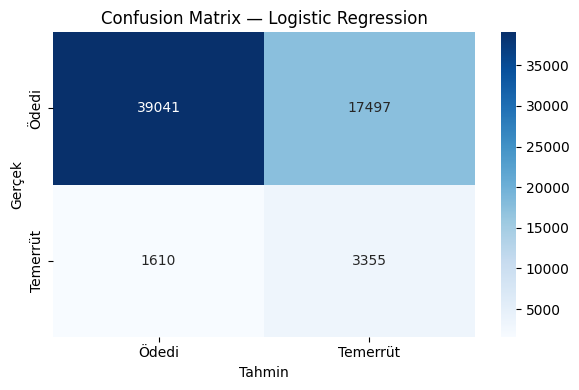

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Logistic Regression tahminleri
cm = confusion_matrix(y_test, y_pred)

# Görselleştir
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ödedi', 'Temerrüt'],
            yticklabels=['Ödedi', 'Temerrüt'])
plt.title('Confusion Matrix — Logistic Regression')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.show()

Gerçek 0, Tahmin 0 → 39.041  (ödeyecek, doğru tahmin)

Gerçek 0, Tahmin 1 → 17.497  (yanlış alarm — gereksiz kredi reddi)

Gerçek 1, Tahmin 0 →  1.610  (kaçırılan temerrüt — en tehlikeli!)

Gerçek 1, Tahmin 1 →  3.355  (temerrüt, doğru yakalandı)

Model 4.965 gerçek temerrütten 3.355'ini yakaladı (%68). 1.610 temerrütü kaçırdı. Banka için bu 1.610 kişi doğrudan kayıp demek.

## **ROC Curve**

ROC Curve — eğri ne kadar sol üst köşeye yakınsa model o kadar iyi.
Kesikli çizgi — rastgele tahmin. Modelimiz bunun çok üzerinde olmalı.

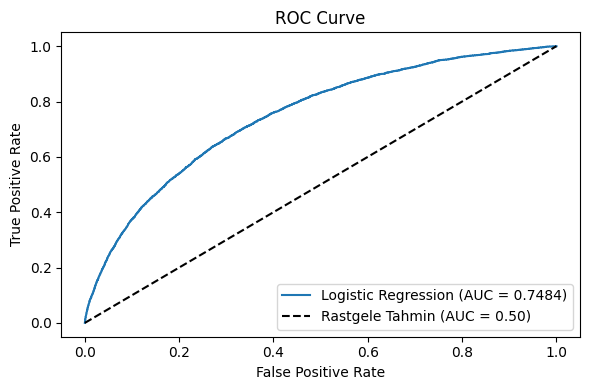

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, model_lr.predict_proba(X_test_scaled)[:, 1])

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = 0.7484)')
plt.plot([0, 1], [0, 1], 'k--', label='Rastgele Tahmin (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

Mavi eğri kesikli çizginin çok üzerinde — modelimiz rastgele tahminden belirgin şekilde daha iyi.

## **Feature Importance Grafiği**


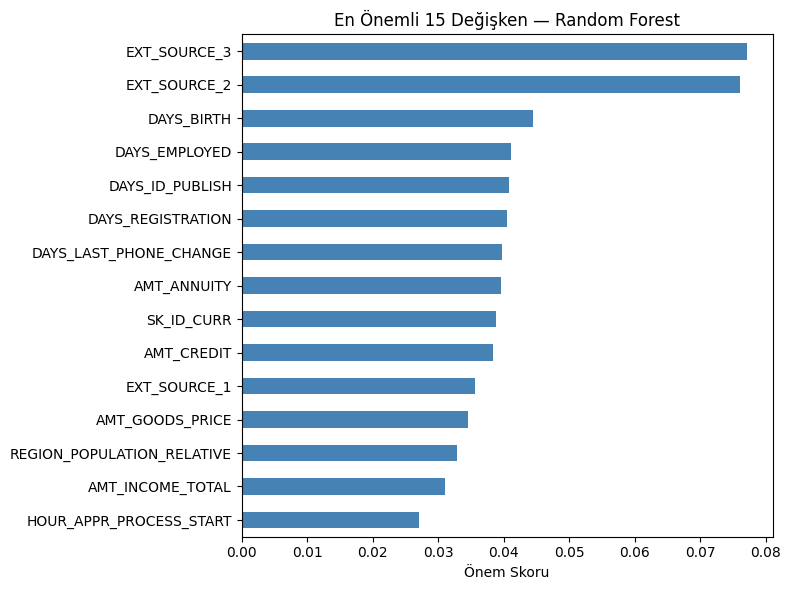

In [ ]:
plt.figure(figsize=(8, 6))
onem.sort_values().plot(kind='barh', color='steelblue')
plt.title('En Önemli 15 Değişken — Random Forest')
plt.xlabel('Önem Skoru')
plt.tight_layout()
plt.show()